# Training Outline
## Zero Shot Training
The purpose of this training is to get the embeddings for use in slider font customization.

# GRID

In [2]:
# Importing
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/home/ljvaughn0841/Projects/TheFontinator/datawork/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 44134.23it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
import torch
from transformers import AutoModel
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)
# Ensure input tensors are also on the 'device'

Using device: cuda


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [4]:
# Ensure you are running on GPU if possible.
print(model.device)

cuda:0


In [5]:
from PIL import Image

def embed_image(image_path):
    image = Image.open(image_path)

    inputs = processor(
        images=image,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        image_features = model.get_image_features(**inputs)

    # Extract the tensor if it's a model output object
    if hasattr(image_features, 'pooler_output'):
        image_features = image_features.pooler_output
    elif hasattr(image_features, 'last_hidden_state'):
        image_features = image_features.last_hidden_state[:, 0, :]  # CLS token

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    return image_features.cpu().numpy()[0]

In [6]:
embed_image("font-photos/silkscreen.png")

array([ 1.91216730e-02,  4.50886339e-02,  3.42306308e-02, -9.89665836e-03,
        5.08010797e-02, -4.10557762e-02,  3.24611105e-02,  2.11373083e-02,
        8.62506125e-03,  7.62014911e-02, -4.64297784e-03, -2.90476531e-02,
        2.47094631e-02, -1.73885822e-02,  6.90666363e-02, -1.64100330e-03,
        2.66347397e-02, -1.85501464e-02,  1.36786932e-03, -1.96293257e-02,
        4.65114368e-03, -3.74057591e-02, -1.10997702e-03,  3.63894887e-02,
       -6.72829002e-02,  2.29769684e-02, -3.46963406e-02,  3.88694406e-02,
       -1.20614807e-03, -1.07901962e-02,  3.94717902e-02,  2.14911997e-03,
        2.55400203e-02, -4.44429833e-03,  1.37761096e-02, -4.24896479e-02,
        5.69172613e-02,  1.80530790e-02, -9.81733436e-04, -8.97927210e-02,
       -1.86972078e-02, -3.01121809e-02, -4.31949981e-02, -5.37303984e-02,
        1.91878639e-02, -1.69929005e-02,  4.24360707e-02, -1.66814681e-02,
       -1.79899833e-03,  5.93782999e-02,  2.39706449e-02,  1.87482336e-03,
        2.23789290e-02,  

In [7]:
import os
import numpy as np
from tqdm import tqdm

image_dir = "font-photos"

embeddings = []
font_ids = []

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        path = os.path.join(image_dir, fname)
        emb = embed_image(path)

        embeddings.append(emb)
        font_ids.append(fname.replace(".png", ""))

embeddings = np.vstack(embeddings)


100%|██████████| 1180/1180 [00:12<00:00, 92.27it/s]


In [8]:
font_ids

['imperialscript',
 'wixmadefortext',
 'prata',
 'gabriela',
 'eduvicwantbeginner',
 'jockeyone',
 'ptserifcaption',
 'eduauvicwantdots',
 'antic',
 'miama',
 'whisper',
 'sourcecodepro',
 'squarepeg',
 'combo',
 'sofia',
 'freeman',
 'crimsontext',
 'almendradisplay',
 'joan',
 'newamsterdam',
 'saira',
 'concertone',
 'newrocker',
 'novasquare',
 'cormorantunicase',
 'plusjakartasans',
 'merienda',
 'candal',
 'libertinusmath',
 'averiasanslibre',
 'prozalibre',
 'spirax',
 'spinnaker',
 'wixmadefordisplay',
 'signikasc',
 'supermercadoone',
 'sedansc',
 'rem',
 'winkysans',
 'mozillatext',
 'kellyslab',
 'portlligatsans',
 'jacquard12charted',
 'rethinksans',
 'twinklestar',
 'ledger',
 'kalniaglaze',
 'bungeehairline',
 'barriecito',
 'bitcountpropdoubleink',
 'miltoniantattoo',
 'cookie',
 'lilex',
 'scopeone',
 'chivo',
 'basic',
 'rubik',
 'librebaskerville',
 'poly',
 'cedarvillecursive',
 'uncialantiqua',
 'federant',
 'greyqo',
 'arbutus',
 'lexendpeta',
 'redditsanscondensed

In [9]:
embeddings

array([[-0.04414342, -0.02710756, -0.0379068 , ...,  0.02207095,
        -0.01793541,  0.01918712],
       [ 0.01636475,  0.02987909,  0.01012276, ...,  0.0007662 ,
        -0.03957109,  0.01309821],
       [-0.0039209 ,  0.0137564 ,  0.00309662, ...,  0.00350844,
        -0.05404161,  0.01702645],
       ...,
       [-0.01281461,  0.04146094, -0.03350754, ...,  0.05729449,
        -0.01539389,  0.01799188],
       [-0.00468115,  0.03108104,  0.02538201, ..., -0.00712608,
        -0.05558039,  0.00967563],
       [-0.0162143 ,  0.02934129,  0.01403423, ...,  0.00792215,
        -0.02980117,  0.00718909]], shape=(1180, 512), dtype=float32)

In [10]:
font_ids.index("silkscreen")

1081

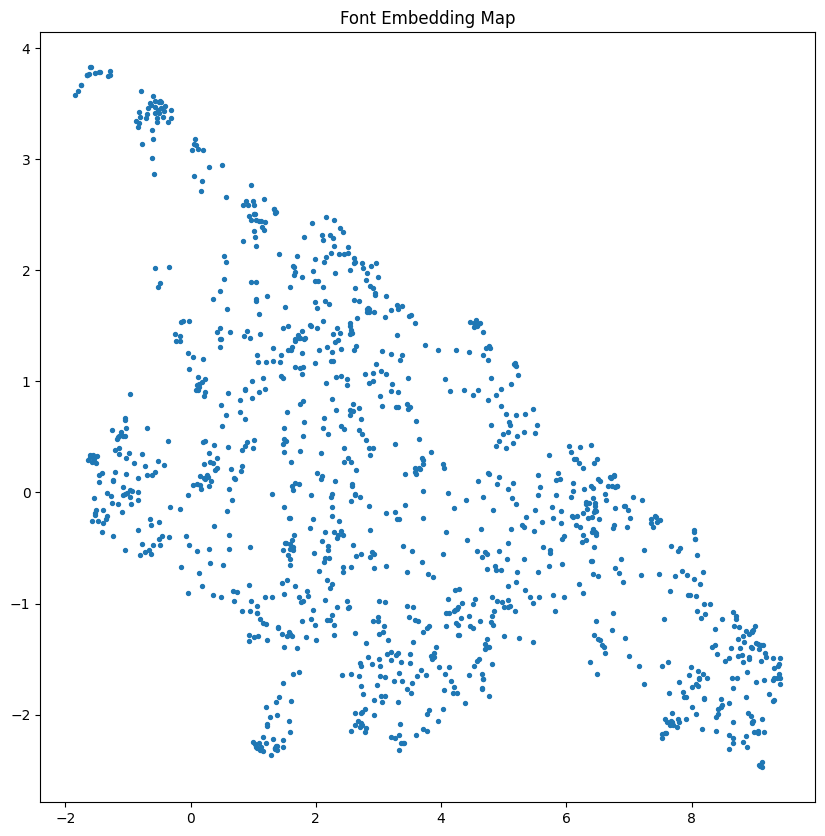

In [11]:
import umap
import matplotlib.pyplot as plt


# Using this to make our 2d embedding map
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine"
)

coords = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 10))
plt.scatter(coords[:, 0], coords[:, 1], s=8)
plt.title("Font Embedding Map")
plt.show()


In [12]:
import numpy as np
from math import ceil, sqrt

n = coords.shape[0]
grid_size = ceil(sqrt(n))

xs = np.linspace(coords[:,0].min(), coords[:,0].max(), grid_size)
ys = np.linspace(coords[:,1].min(), coords[:,1].max(), grid_size)

grid = np.array([
    (x, y)
    for y in ys
    for x in xs
])[:n]


In [13]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

cost = cdist(coords, grid)
row_ind, col_ind = linear_sum_assignment(cost)

grid_coords = grid[col_ind]

# After computing grid_coords = grid[col_ind]

# Compute integer grid positions
grid_size = ceil(sqrt(n))
integer_grid_coords = np.array([[idx // grid_size, idx % grid_size] for idx in col_ind])

# Save the integer Grid Coords instead
proj_dir = os.getcwd().rsplit('/', 1)[0]
np.save(proj_dir + '/backend/data/GridCoords', integer_grid_coords)


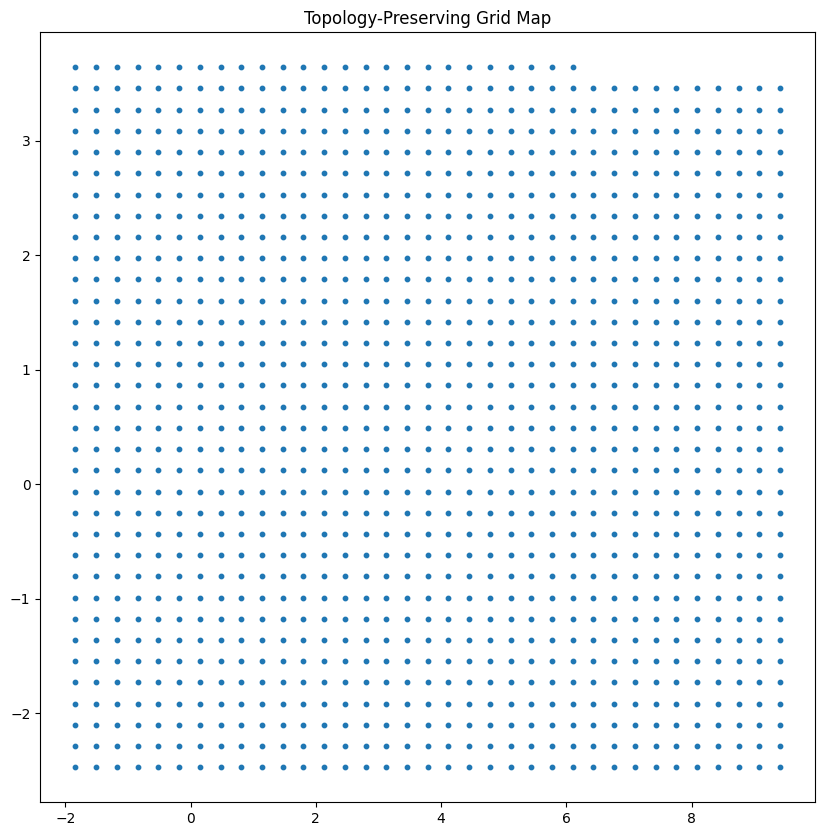

In [14]:
plt.figure(figsize=(10, 10))
plt.scatter(grid_coords[:, 0], grid_coords[:, 1], s=10)
plt.title("Topology-Preserving Grid Map")
plt.show()


In [15]:
# Grid Coords still match up in order of font_ids
grid_coords

array([[ 9.081244  ,  1.9749815 ],
       [ 2.4638324 ,  3.2726662 ],
       [ 2.794703  , -1.7326901 ],
       ...,
       [ 7.7577624 , -1.9180737 ],
       [-0.844874  ,  0.86267996],
       [ 8.088633  ,  0.12114573]], shape=(1180, 2), dtype=float32)

In [16]:
# Save the Grid Coords and the id's for use in backend
proj_dir = os.getcwd().rsplit('/', 1)[0]
np.save(proj_dir + '/backend/data/GridCoords', grid_coords)

# Named font data because I'll probably expand this table to have metadata
# Converts to numpy for now
font_ids_np = np.array(font_ids)
np.save(proj_dir + '/backend/data/FontData', font_ids_np)

In [17]:
font_ids_np

array(['imperialscript', 'wixmadefortext', 'prata', ..., 'alexbrush',
       'gluten', 'jimnightshade'], shape=(1180,), dtype='<U28')

# Embedding Sliders

buisness, fancy, calm, playfull, cute, artistic, vintage, loud, sophisticated, futuristic, active, stiff, innovative, happy, childlike, rugged, awkward, excited

In [ ]:
sliders = {
    "seriousness": [
        "serious professional corporate font",
        "playful fun cartoon font"
    ],
    "modernness": [
        "modern clean minimalist font",
        "classic traditional old font"
    ],
    "elegance": [
        "elegant luxury fashion font",
        "loud bold display font"
    ],
    "personal": [
        "human handwritten script font",
        "technical computer font"
    ],
    "energy": [
    "energetic dynamic expressive font",
    "calm stable restrained font"
    ],
    "density": [
      "compact dense information-heavy font",
      "open airy spacious font"
    ],
    "readability": [
    "highly readable clear body text font",
    "expressive decorative hard to read font"
    ]
}


In [ ]:
# classes = [] # get all slider values in here

In [24]:
sliders["seriousness"]

['serious professional corporate font', 'playful fun cartoon font']

In [25]:
img_emb = embed_image("font-photos/alexbrush.png")

In [ ]:
image_dir = "font-photos"

for slider in sliders:
  img_probs = None
  # embeddings = []

  slider_font_ids = []

  for fname in tqdm(os.listdir(image_dir)):
      if fname.endswith(".png"):
          image_path = os.path.join(image_dir, fname)
          image = Image.open(image_path)
          inputs = processor(text=classes, images=image, return_tensors="pt", padding=True, do_convert_rgb=False)
          outputs = model(**inputs)

          logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
          probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

          img_probs.append(emb)
          slider_font_ids.append(fname.replace(".png", ""))

probabilities = np.vstack(img_probs)

  0%|          | 0/1180 [00:00<?, ?it/s]


ValueError: Unsupported number of image dimensions: 2

In [ ]:
classes = ['giraffe', 'zebra', 'elephant']

inputs = processor(text=classes, images=images, return_tensors="pt", padding=True, do_convert_rgb=False)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

In [ ]:
image_dir = "font-photos"

embeddings = []
font_ids = []

for fname in tqdm(os.listdir(image_dir)):
    if fname.endswith(".png"):
        path = os.path.join(image_dir, fname)

        emb = embed_image(path)

        embeddings.append(emb)
        font_ids.append(fname.replace(".png", ""))

embeddings = np.vstack(embeddings)


In [22]:
grid_coords = np.load(proj_dir + '/backend/data/GridCoords.npy')

In [24]:
grid_coords

array([[ 2.895771 ,  8.435083 ],
       [ 7.9715347,  4.027959 ],
       [ 8.568684 , 10.363201 ],
       ...,
       [ 4.0900683, 11.189537 ],
       [11.554426 ,  5.956076 ],
       [ 2.895771 ,  4.854295 ]], shape=(1180, 2), dtype=float32)

In [29]:
# Add this code after loading grid_coords to convert the float coordinates to integer grid positions

import numpy as np
from math import ceil, sqrt

# Assuming grid_coords is the loaded 1180x2 array
n = grid_coords.shape[0]
grid_size = ceil(sqrt(n))

# Recreate xs and ys (assuming coords is available from earlier, or load embeddings and recompute)
# If coords is not available, you need to recompute or load it
# For now, assuming coords is available from the UMAP step

# If not, you can approximate min and max from grid_coords itself, but better to use original
# To be precise, let's assume we recompute xs and ys based on the original coords

# But since the notebook has coords from UMAP, in practice, run this after the UMAP cell.

# For this code, assuming coords is defined.

xs = np.linspace(grid_coords[:,0].min(), grid_coords[:,0].max(), grid_size)
ys = np.linspace(grid_coords[:,1].min(), grid_coords[:,1].max(), grid_size)

# Now, for each point in grid_coords, find the closest row and col
integer_grid_coords = []
for x, y in grid_coords:
    col = np.argmin(np.abs(xs - x))
    row = np.argmin(np.abs(ys - y))
    integer_grid_coords.append([row, col])

integer_grid_coords = np.array(integer_grid_coords)

# Now integer_grid_coords is a 1180x2 array of integers representing row, col
print(integer_grid_coords)

# Optionally, save it
proj_dir = os.getcwd().rsplit('/', 1)[0]
np.save(proj_dir + '/backend/data/GridCoords_integers', integer_grid_coords)

[[22  2]
 [ 5 19]
 [29 21]
 ...
 [32  6]
 [12 31]
 [ 8  2]]
